In [69]:
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow_datasets as tfds
from tensorflow.keras.layers import InputLayer,Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

In [2]:
dataset , dataset_info = tfds.load('malaria',with_info=True,as_supervised=True,split=['train[:80%]', 'train[80%:]']) # with_info is by  default false , as_supervised is true to get (image,label) tuple

In [3]:
dataset_info # Provide information about the dataset

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='C:\\Users\\HP\\tensorflow_datasets\\malaria\\1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved mala

In [4]:
dataset

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

In [5]:
print(type(dataset))     # should show <class 'list'>
print(len(dataset))      # number of splits returned

for i, ds in enumerate(dataset):
    print(f"\n--- Split {i} ---")
    print("Type:", type(ds))
    print("Element spec:", ds.element_spec)


<class 'list'>
2

--- Split 0 ---
Type: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
Element spec: (TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))

--- Split 1 ---
Type: <class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
Element spec: (TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))


In [6]:
print(dataset_info.splits['train'].num_examples)   # total images
print("Train (80%):", int(0.8 * dataset_info.splits['train'].num_examples))
print("Test  (20%):", int(0.2 * dataset_info.splits['train'].num_examples))


27558
Train (80%): 22046
Test  (20%): 5511


In [37]:
def splits_dataset(dataset,TRAIN_RATIO,VAL_RATIO,TEST_RATIO):
  DATASET_SIZE = len(dataset)
  train_dataset = dataset.take(int(TRAIN_RATIO * DATASET_SIZE))
  val_test_dataset = dataset.skip(int(TRAIN_RATIO * DATASET_SIZE))
  val_dataset = val_test_dataset.take(int(VAL_RATIO * DATASET_SIZE))
  test_dataset = val_test_dataset.skip(int(VAL_RATIO * DATASET_SIZE))
  return train_dataset, val_dataset, test_dataset

In [51]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

train_dataset,test_dataset,val_dataset = splits_dataset(dataset[0],TRAIN_RATIO,VAL_RATIO,TEST_RATIO)

print(f"The len of the train dataset is :{len(train_dataset)}")
print(f"The len of the test dataset is :{len(test_dataset)}")
print(f"The len of the val dataset is :{len(val_dataset)}")


The len of the train dataset is :17636
The len of the test dataset is :2204
The len of the val dataset is :2206


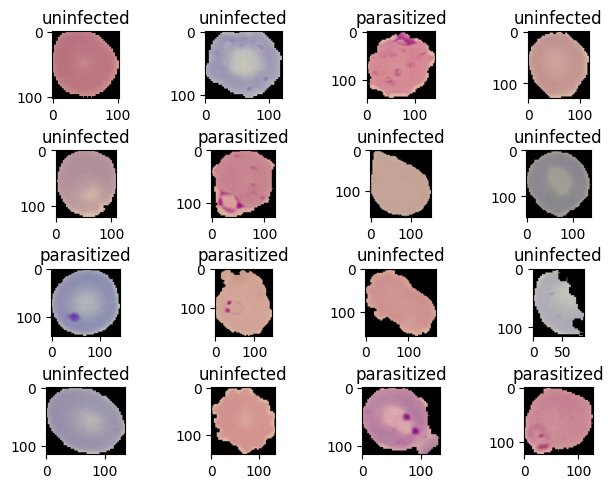

In [52]:
for i,(image,label) in enumerate(train_dataset.take(16)):
    ax = plt.subplot(4, 4, i + 1)
    ax.imshow(image)
    plt.title(dataset_info.features['label'].int2str(label))
plt.tight_layout(pad=0.4)   # pad controls spacing between images
plt.show()

#### Data Preprocessing

In [53]:
IM_SIZE = 224
def resizing(image,label):
  return tf.image.resize(image,(IM_SIZE,IM_SIZE))/255.0,label

In [ ]:
train_dataset = train_dataset.map(resizing)
val_dataset = val_dataset.map(resizing)
test_dataset = test_dataset.map(resizing)

In [55]:
for image,label in train_dataset.take(1):
  print(image)

tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(224, 224, 3), dtype=float32)


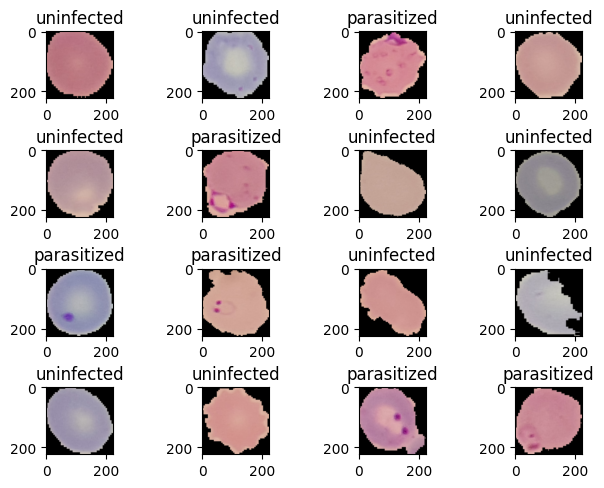

In [56]:
for i,(image,label) in enumerate(train_dataset.take(16)):
    ax = plt.subplot(4, 4, i + 1)
    ax.imshow(image)
    plt.title(dataset_info.features['label'].int2str(label))
plt.tight_layout(pad=0.4)   # pad controls spacing between images
plt.show()

In [57]:
val_dataset = val_dataset.shuffle(buffer_size=8,reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)

In [58]:
train_dataset = train_dataset.shuffle(buffer_size=8,reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)

#### Model Creation

In [70]:
model = tf.keras.Sequential([
  InputLayer(shape=(IM_SIZE,IM_SIZE,3)),
  Conv2D(filters=6,kernel_size=5,strides=1,padding='valid',activation='relu'),
  BatchNormalization(),
  MaxPooling2D(pool_size=2,strides=2),

  Conv2D(filters=16,kernel_size=5,strides=1,padding='valid',activation='relu'),
  BatchNormalization(),
  MaxPooling2D(pool_size=2,strides=2),

  Flatten(),

  Dense(1000,activation='relu'),
  BatchNormalization(),

  Dense(10,activation='relu'),
  BatchNormalization(),

  Dense(1,activation='sigmoid')
])

In [71]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 220, 220, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 220, 220, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 110, 110, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 106, 106, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 106, 106, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 53, 53, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 44944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1000)           │    44,945,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │        10,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,962,021 (171.52 MB)

 Trainable params: 44,959,957 (171.51 MB)

 Non-trainable params: 2,064 (8.06 KB)

In [72]:
model.compile(
  optimizer=Adam(learning_rate=0.01),
  loss = BinaryCrossentropy(from_logits=True),
  metrics = ['accuracy']
)

In [73]:
history = model.fit(train_dataset,validation_data=val_dataset,epochs=5,verbose=1)

Epoch 1/5


d:\Coding\tensorflow\.venv\Lib\site-packages\keras\src\backend\tensorflow\nn.py:789: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


552/552 ━━━━━━━━━━━━━━━━━━━━ 355s 620ms/step - accuracy: 0.7301 - loss: 0.5409 - val_accuracy: 0.9021 - val_loss: 0.3094
Epoch 2/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 548s 994ms/step - accuracy: 0.9317 - loss: 0.2046 - val_accuracy: 0.9343 - val_loss: 0.1834
Epoch 3/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 542s 980ms/step - accuracy: 0.9430 - loss: 0.1685 - val_accuracy: 0.9234 - val_loss: 0.2218
Epoch 4/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 286s 519ms/step - accuracy: 0.9469 - loss: 0.1598 - val_accuracy: 0.9284 - val_loss: 0.2309
Epoch 5/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 323s 585ms/step - accuracy: 0.9520 - loss: 0.1386 - val_accuracy: 0.9383 - val_loss: 0.2163


In [75]:
history.history

{'accuracy': [0.8246200680732727,
  0.9336584210395813,
  0.9427307844161987,
  0.9436947107315063,
  0.9539577960968018],
 'loss': [0.3997921645641327,
  0.2026723325252533,
  0.1725306212902069,
  0.1664777398109436,
  0.13740646839141846],
 'val_accuracy': [0.9020852446556091,
  0.9342701435089111,
  0.9233907461166382,
  0.9283771514892578,
  0.9383499622344971],
 'val_loss': [0.309373676776886,
  0.18338432908058167,
  0.221797376871109,
  0.23088832199573517,
  0.21625857055187225]}

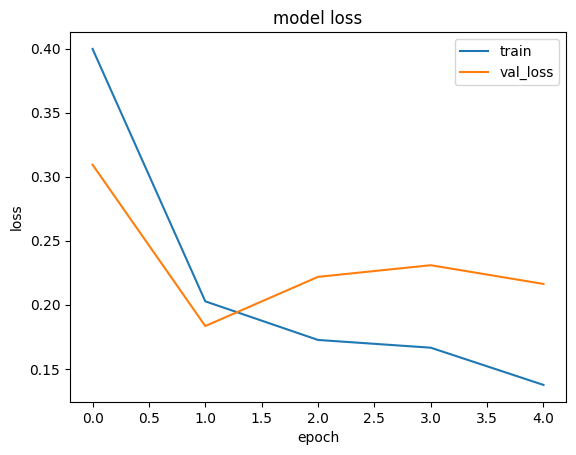

In [76]:
plt.plot(history.history["loss"])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val_loss'])
plt.show()

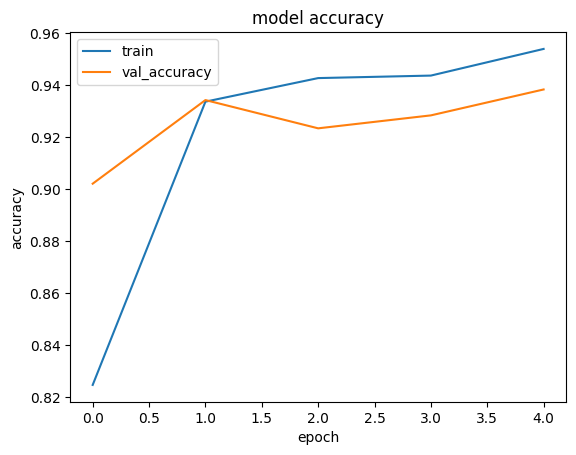

In [77]:
plt.plot(history.history["accuracy"])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val_accuracy'])
plt.show()

In [78]:
test_dataset = test_dataset.batch(1)

In [81]:
predicted = model.evaluate(test_dataset)

2204/2204 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9456 - loss: 0.1908


In [82]:
def parasite_or_not(x):
  if(x<0.5):
    return str("Parasitized")
  else:
    return str("Uninfected")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


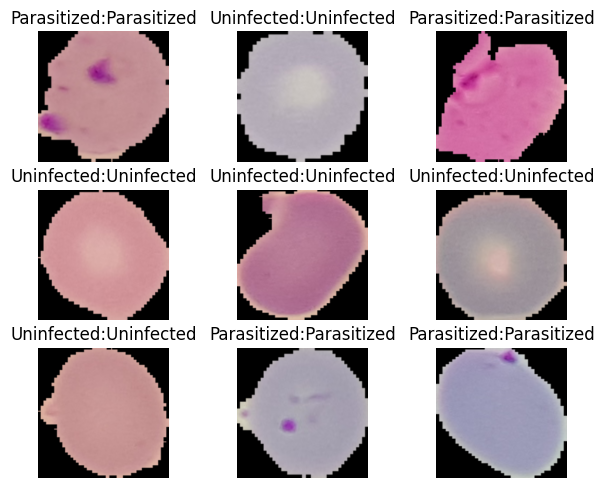

In [83]:
for i,(image,label) in enumerate(test_dataset.take(9)):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image[0])
  plt.title(str(parasite_or_not(label.numpy()[0])) + ":" + str(parasite_or_not(model.predict(image)[0][0])))
  plt.axis('off')
plt.tight_layout(pad=0.4)   # pad controls spacing between images
